In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from pathlib import Path
import sys

MAL_DIR = Path.cwd()
if MAL_DIR.name != "MAL":
    MAL_DIR = next(path for path in [Path.cwd(), *Path.cwd().parents] if path.name == "MAL")

sys.path.insert(0, str(MAL_DIR))

from scripts.preprocessing import AutomatedPreprocessor

#here we import and split the data
df = pd.read_csv("../../data/processed/linearized_session_windows_30min.csv")

TARGET_COLUMN = "focus_score"
columns_to_ignore = [TARGET_COLUMN]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [ ]:
# Linear Regression with ElasticNet (Ridge + Lasso penalties)

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, make_scorer
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore convergence warnings that occur when alpha=0 (no penalty)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Preprocess validation set
X_val_processed = preprocessor.transform(X_val)

# Handle bounds and round for classification-like accuracy
def get_rounded_acc(y_true, y_pred_cont):
    clipped = np.clip(y_pred_cont, 1, 5)
    rounded = np.round(clipped).astype(int)
    return accuracy_score(y_true, rounded)

# Create a custom scorer to track accuracy during Cross-Validation
rounded_acc_scorer = make_scorer(get_rounded_acc)

# 1. Hyperparameter tuning for both Ridge (L2) and Lasso (L1) aspects
param_grid = {
    'alpha': [0.0, 0.001, 0.01, 0.1, 1.0, 10.0], # 0.0 = no penalty (standard linear regression)
    'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0] # 0.0 = pure Ridge, 1.0 = pure Lasso
}

elastic_net = ElasticNet(max_iter=10000)

# Evaluate using BOTH Mean Squared Error and Custom Accuracy during CV
grid_search = GridSearchCV(
    elastic_net, 
    param_grid, 
    cv=5, 
    scoring={'neg_MSE': 'neg_mean_squared_error', 'Accuracy': rounded_acc_scorer},
    refit='neg_MSE' # We still optimize hyperparameters to minimize MSE
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
best_index = grid_search.best_index_
print(f"Best Parameters (optimized for MSE): {grid_search.best_params_}")

# Display the 5-fold CV accuracies for the best performing model
cv_accuracies = [
    grid_search.cv_results_[f'split{i}_test_Accuracy'][best_index] 
    for i in range(5)
]
print(f"5-Fold CV Accuracies for Best Model: {[f'{acc*100:.2f}%' for acc in cv_accuracies]}")
print(f"Mean CV Accuracy: {np.mean(cv_accuracies)*100:.2f}% (std: {np.std(cv_accuracies)*100:.2f}%)")

# 2. Predict on Train and Validation sets
y_train_pred_cont = best_model.predict(X_train_processed)
y_val_pred_cont = best_model.predict(X_val_processed)

# 3. Metrics Evaluated on Train and Validation Set
acc_train = get_rounded_acc(y_train, y_train_pred_cont)
acc_val = get_rounded_acc(y_val, y_val_pred_cont)
mse = mean_squared_error(y_val, y_val_pred_cont)
r2 = r2_score(y_val, y_val_pred_cont)

print(f"\nGeneralized Linear Regression Results:")
print(f"Train Accuracy: {acc_train * 100:.2f}%")
print(f"Validation Accuracy: {acc_val * 100:.2f}%")
print(f"Validation Mean Squared Error: {mse:.4f}")
print(f"Validation R2 Score: {r2:.4f}")

# Plotting actual vs predicted (Validation Set)
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_val_pred_cont, alpha=0.5)
plt.plot([1, 5], [1, 5], '--r')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (ElasticNet - Validation Set)")
plt.show()

C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Us


--- Train Metrics ---
MSE:  0.1620
RMSE: 0.4024
MAE:  0.3017
R2:   0.4690

--- Test/Validation Metrics ---
MSE:  0.1761
RMSE: 0.4196
MAE:  0.3151
R2:   0.4248

--- Model Coefficients (Top 20 by Absolute Value) ---
std30minCO2                                                                                 0.229103
std30minTemp                                                                               -0.225222
max30minLight_std30minLight                                                                 0.201670
min30minLight_mean30minLight                                                                0.188040
max30minCO2_min30minCO2_mean30minCO2_min30minHumidity_max30minHumidity_mean30minHumidity   -0.052539
std30minHumidity_trend30minHumidity_trend30minCO2                                          -0.029599
min30minTemp_max30minTemp_mean30minTemp                                                    -0.022452
trend30minTemp                                                                

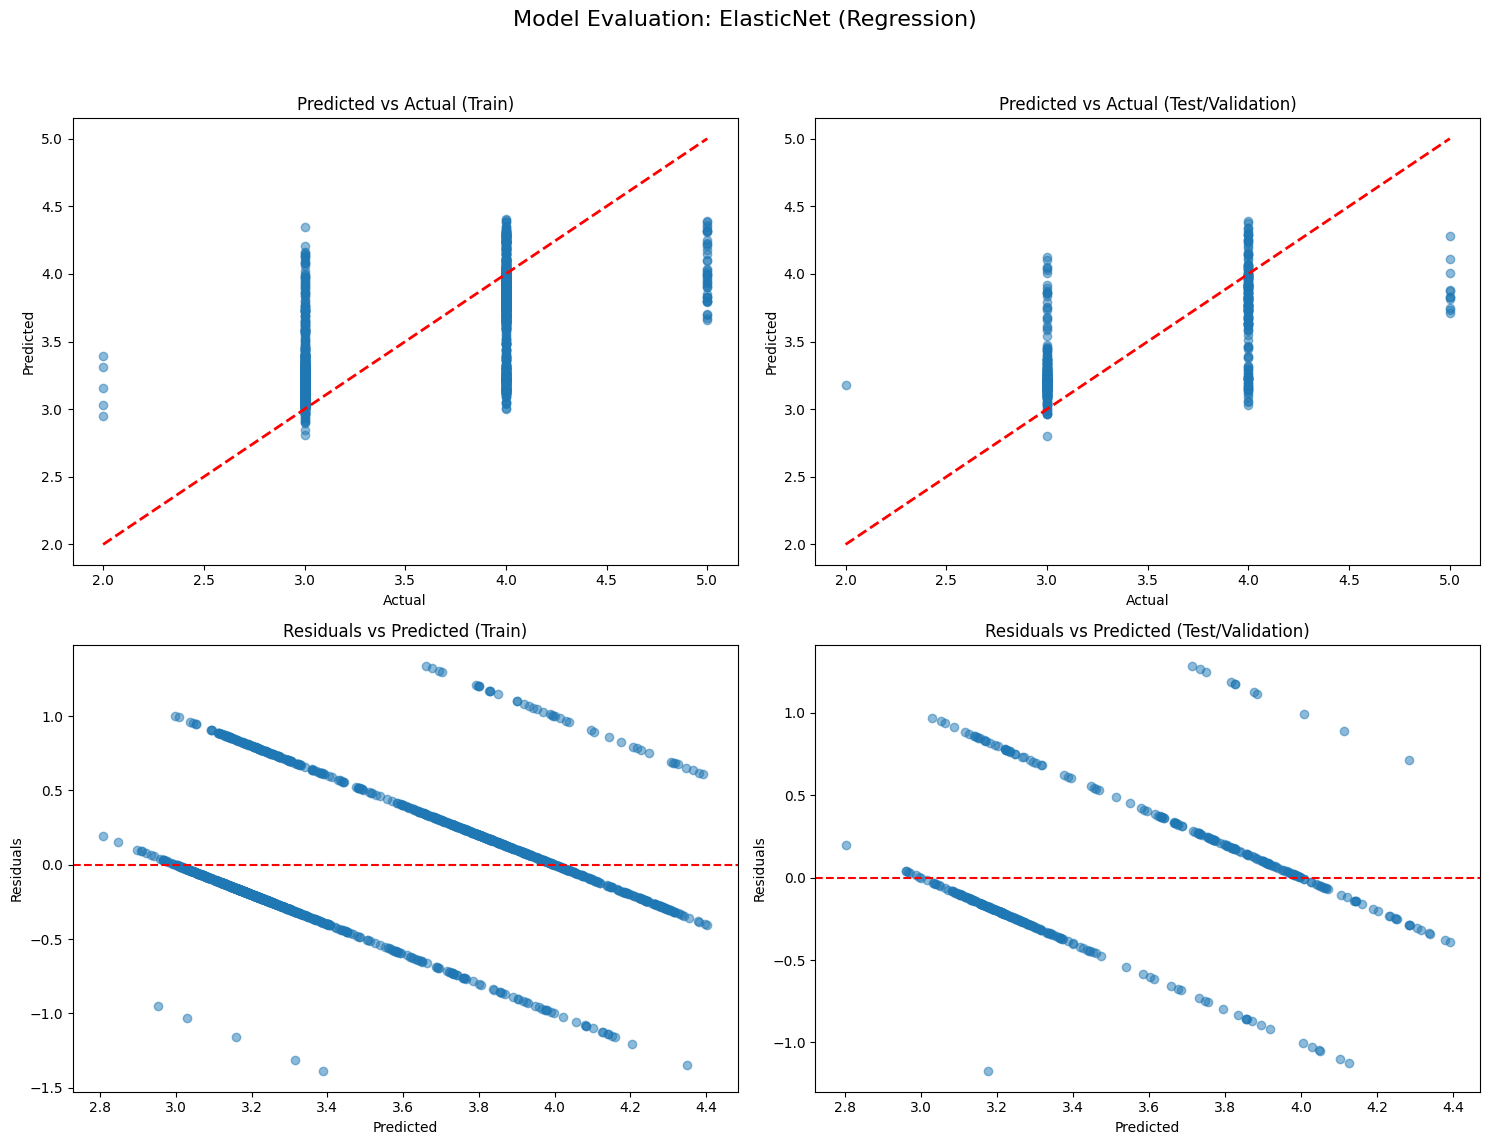

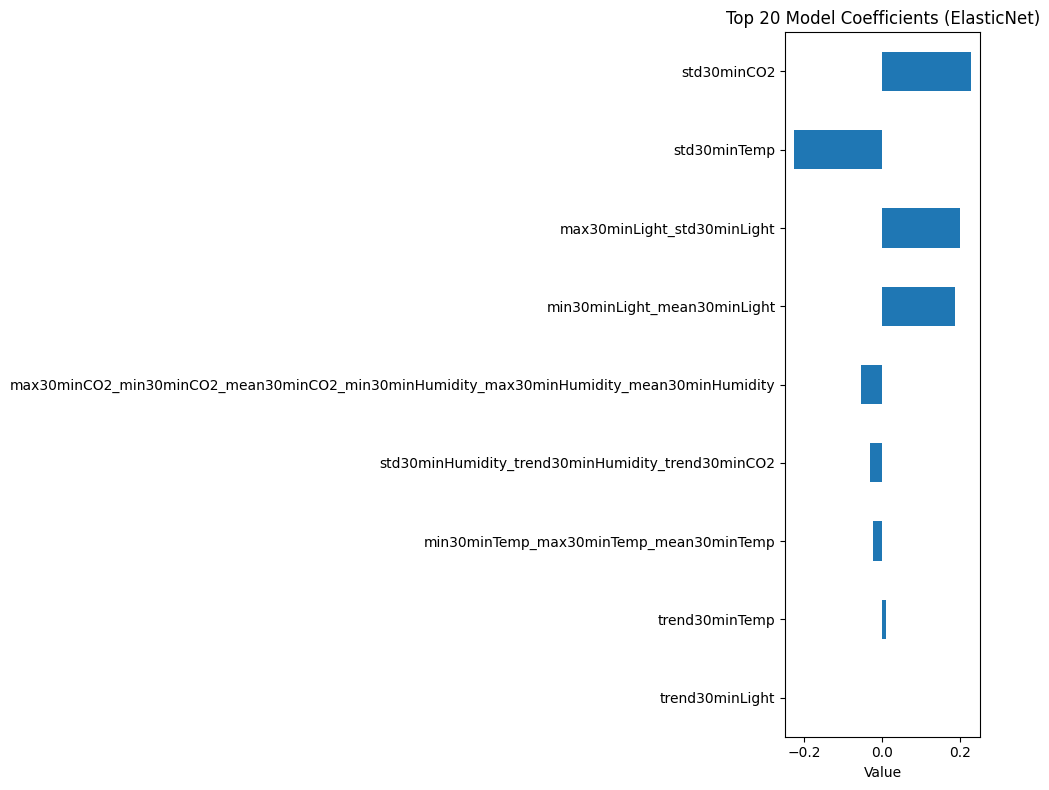

In [ ]:
import importlib
import scripts.evaluation_metrics
importlib.reload(scripts.evaluation_metrics)
from scripts.evaluation_metrics import evaluate_model
best_model = ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=10000)
best_model.fit(X_train_processed, y_train)


evaluate_model(best_model, X_train_processed, X_val_processed, y_train, y_val, False);


## Conclusion

Linear models provide a solid baseline for the rating prediction task. ElasticNet was chosen in order to experiment with both Lasso and Ridge regressions together or not.

While models like ElasticNet are extremely fast and highly explainable, their R2 scores remain relatively low compared to the classification accuracy seen in Neural Networks (Notebook 4) or Random Forests (Notebook 6). This suggests that the relationship between environmental factors and student focus is likely non-linear. 

The primary advantage here is the ability to see exactly which features (like temperature or CO2 trends) drive the rating. However, because we are treating 'rating' as a continuous value here and the model often predicts 'in-between' ratings that don't exist. Our problem type is more likely classification, even though it was interesting to experiment with regression here.

For the problem in our SEP project, linear regression is a great tool for initial feature importance analysis, but it is likely too simple to be our primary prediction engine.
